# Data Sanity Check

This notebook explores the `raw_listings` table from SQLite in order to revise the basic quality of the data.

## Section 1 — Load and overview

Connect to SQLite, load `raw_listings` into a DataFrame, show shape, dtypes, head, counts by source, and counts by timestamp.

In [23]:
import sqlite3
import pandas as pd

db_path = "../data/hardware_pulse.db"
con = sqlite3.connect(db_path)

df = pd.read_sql_query("SELECT * FROM raw_listings", con)
con.close()

print("DataFrame loaded successfully")

df.shape

DataFrame loaded successfully


(338, 15)

In [24]:
df.dtypes

id                      int64
listing_key               str
source                    str
item_id                object
url                       str
timestamp                 str
title                     str
price                 float64
currency                  str
seller                    str
condition                 str
available_quantity     object
base_price             object
created_at                str
updated_at                str
dtype: object

In [25]:
df.head(10)

,id,listing_key,source,item_id,url,timestamp,title,price,currency,seller,condition,available_quantity,base_price,created_at,updated_at
0,1,3091de08fdf533025f6c7283d5ebf51a29f99a4c7aed2d...,thot,None,https://thotcomputacion.com.uy/producto/antec-...,2026-04-24T21:16:19.477725+00:00,Antec Riser Cable Vertical GPU AT-RCVB-BK200-P...,20.00,USD,thot,new,None,None,2026-04-24T21:16:42.631433+00:00,2026-04-24T21:16:42.631433+00:00
1,2,fecd0d9b1e93b8218abc62b72707aadc116c39bf21499e...,thot,None,https://thotcomputacion.com.uy/producto/antec-...,2026-04-24T21:16:19.477725+00:00,Antec Riser Cable Vertical GPU AT-RCVB-W200-PC...,20.00,USD,thot,new,None,None,2026-04-24T21:16:42.633435+00:00,2026-04-24T21:16:42.633435+00:00
2,3,8e83870019e8f85906854d82a94cf0f3ddd34c0afc8d7e...,thot,None,https://thotcomputacion.com.uy/producto/msi-ge...,2026-04-24T21:16:19.477725+00:00,MSI GeForce G210 1Gb Ddr3 LP,44.99,USD,thot,new,None,None,2026-04-24T21:16:42.635328+00:00,2026-04-24T21:16:42.635328+00:00
3,4,4b6ea70e0968d399b2c46d8c92e01e17a02dc501c0b2a5...,thot,None,https://thotcomputacion.com.uy/producto/gpu-bi...,2026-04-24T21:16:19.477725+00:00,GPU Biostar GeForce G210 1Gb GDDR3,44.99,USD,thot,new,None,None,2026-04-24T21:16:42.636340+00:00,2026-04-24T21:16:42.636340+00:00
4,5,96c6abb4fee1cb08fbb532a0e38473c87c423a970875be...,thot,None,https://thotcomputacion.com.uy/producto/biosta...,2026-04-24T21:16:19.477725+00:00,Biostar Radeon RX550 4gb ddr5,125.00,USD,thot,new,None,None,2026-04-24T21:16:42.637338+00:00,2026-04-24T21:16:42.637338+00:00
5,6,70450c88404aa7f549eaf028738ad3a2d451503c8e506e...,thot,None,https://thotcomputacion.com.uy/producto/gpu-pa...,2026-04-24T21:16:19.477725+00:00,GPU Palit GeForce RTX3050 Stormx 6GB DDR6,280.00,USD,thot,new,None,None,2026-04-24T21:16:42.638338+00:00,2026-04-24T21:16:42.638338+00:00
6,7,c3d5e02faf94c70e2b258d49ddbf69bfe12403cda87129...,thot,None,https://thotcomputacion.com.uy/producto/gpu-ms...,2026-04-24T21:16:19.477725+00:00,GPU MSI GeForce RTX 3050 LP OC 6Gb DDR6,285.00,USD,thot,new,None,None,2026-04-24T21:16:42.642339+00:00,2026-04-24T21:16:42.642339+00:00
7,8,721969106e6722c34d16a6d4213b9796094db16d849e89...,thot,None,https://thotcomputacion.com.uy/producto/gpu-gi...,2026-04-24T21:16:19.477725+00:00,GPU Gigabyte GeForce RTX3050 Windforce OC 6Gb,285.00,USD,thot,new,None,None,2026-04-24T21:16:42.643339+00:00,2026-04-24T21:16:42.643339+00:00
8,9,d7c6149d45e69d4b8ded8a5899c60bae15e233078fd97b...,thot,None,https://thotcomputacion.com.uy/producto/gpu-ms...,2026-04-24T21:16:19.477725+00:00,GPU MSI GeForce RTX 3050 Ventus X2 OC 6Gb DDR6,289.99,USD,thot,new,None,None,2026-04-24T21:16:42.645484+00:00,2026-04-24T21:16:42.645484+00:00
9,10,2aa8f1e949acb8f444679f28ff9f3287437ffbe3b45c64...,thot,None,https://thotcomputacion.com.uy/producto/gpu-as...,2026-04-24T21:16:19.477725+00:00,GPU ASrock Intel Arc A580 Challenger 8Gb DDR6,295.00,USD,thot,new,None,None,2026-04-24T21:16:42.646495+00:00,2026-04-24T21:16:42.646495+00:00


In [26]:
if "source" in df.columns:
    print("Records by source:")
    display(df["source"].value_counts(dropna=False))
else:
    print("Column 'source' does not exist in the DataFrame")

if "timestamp" in df.columns:
    df["run_date"] = pd.to_datetime(df["timestamp"], errors="coerce").dt.date
    print("\nRecords by run date (run_date):")
    display(df["run_date"].value_counts().sort_index())
    print("\nRecords by timestamp:")
    display(df["timestamp"].value_counts(dropna=False).sort_index())
else:
    print("Column 'timestamp' does not exist in the DataFrame")

Records by source:


source
thot       138
banifox    136
pccompu     64
Name: count, dtype: int64


Records by run date (run_date):


run_date
2026-04-24    308
2026-04-26     30
Name: count, dtype: int64


Records by timestamp:


timestamp
2026-04-24T21:16:19.477725+00:00    55
2026-04-24T21:16:42.717811+00:00    83
2026-04-24T21:17:14.168914+00:00    49
2026-04-24T21:17:23.305704+00:00    87
2026-04-24T21:17:33.780498+00:00    34
2026-04-26T21:32:47.740429+00:00    30
Name: count, dtype: int64

## Section 2 — Prices

Explore the `price` column, inspect the distribution by `currency`, plot a histogram/boxplot by `source`, and identify obvious USD outliers.

count     338.000000
mean      533.951361
std       535.563856
min         3.000000
25%       239.000000
50%       426.000000
75%       674.500000
max      6159.000000
Name: price, dtype: float64

Distribution by currency:


currency
USD    338
Name: count, dtype: int64

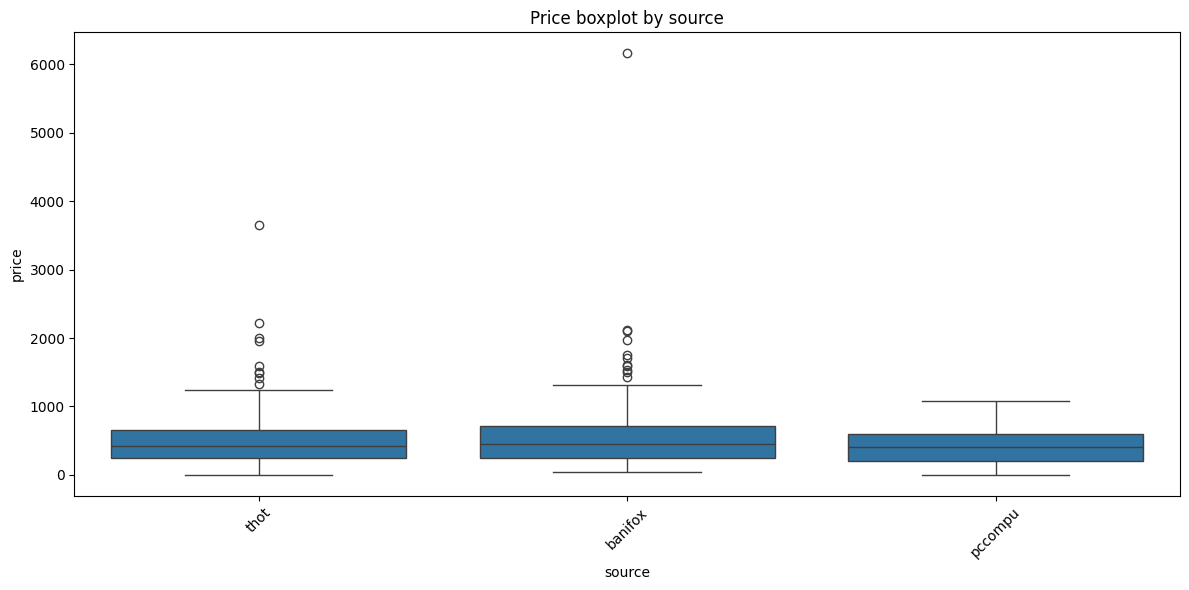

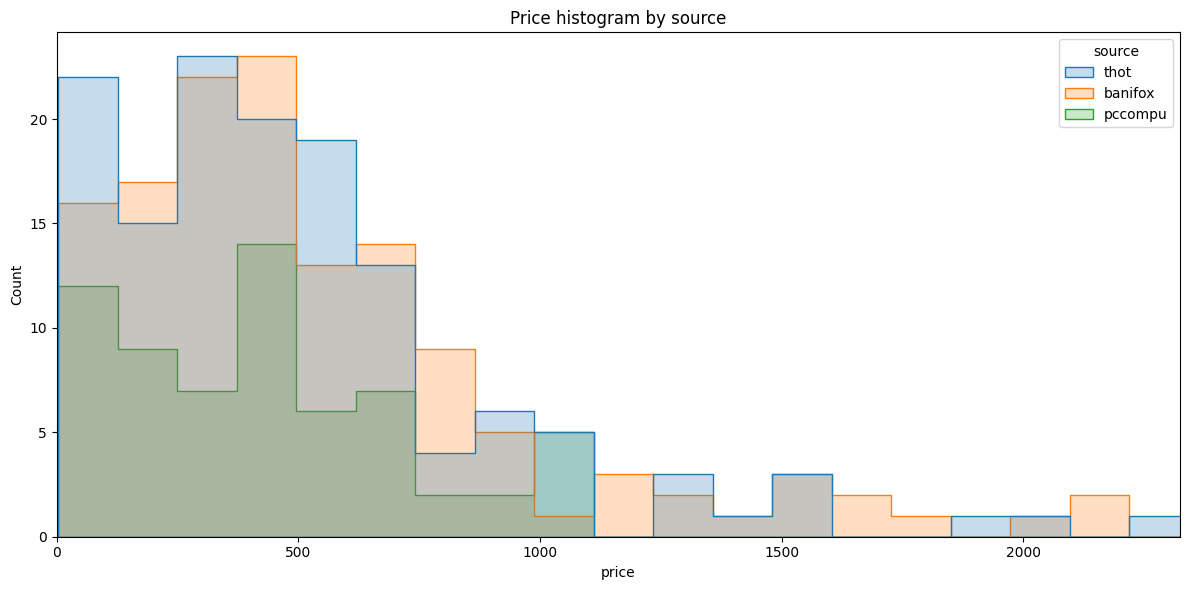

Obvious USD outliers (price < 10 or > 10000): 4 records


,price,currency,source
55,5.0,USD,thot
56,6.0,USD,thot
57,7.0,USD,thot
332,3.0,USD,pccompu


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

price_col = "price"
if price_col in df.columns:
    df[price_col] = pd.to_numeric(df[price_col], errors="coerce")
    display(df[price_col].describe())
else:
    raise KeyError(f"Column {price_col} not found")

if "currency" in df.columns:
    print("Distribution by currency:")
    display(df["currency"].value_counts(dropna=False))
else:
    print("Column 'currency' does not exist in the DataFrame")

if "source" in df.columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x="source", y=price_col, data=df)
    plt.title("Price boxplot by source")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 6))
    sns.histplot(data=df, x=price_col, hue="source", element="step", stat="count", bins=50, common_norm=False)
    plt.title("Price histogram by source")
    plt.xlim(0, df[price_col].quantile(0.99) * 1.1)
    plt.tight_layout()
    plt.show()
else:
    print("Column 'source' does not exist for plotting prices by source")

usd_mask = df[price_col].notna()
if "currency" in df.columns:
    usd_mask &= df["currency"].astype(str).str.upper() == "USD"

outliers = df.loc[usd_mask & ((df[price_col] < 10) | (df[price_col] > 10000)), [price_col, "currency", "source"] if "source" in df.columns else [price_col, "currency"]]
print(f"Obvious USD outliers (price < 10 or > 10000): {len(outliers)} records")
display(outliers.head(20))

In [28]:
df_component = df[df["price"] >= 43]
len(df_component)

326

## Section 3 — Titles

Extract a sample of 10 titles by source, try to capture the chipset with a simple regex, and count matches.

In [29]:
if "title" not in df.columns:
    raise KeyError("Column 'title' not found in the DataFrame")

pattern = r"RTX\s?\d{4}|RX\s?\d{4}"

if "source" in df.columns:
    for source, group in df.groupby("source"):
        print(f"\nSource: {source}")
        display(group["title"].head(10))
else:
    print("Column 'source' does not exist; showing 10 random titles")
    display(df["title"].sample(10, random_state=42))

matches = df["title"].astype(str).str.contains(pattern, regex=True, case=False, na=False)
print(f"\nTitles matching the pattern '{pattern}': {matches.sum()}")
print(f"Titles NOT matching: {(~matches).sum()}")

sample_matches = df.loc[matches, ["title"]].head(10)
sample_non_matches = df.loc[~matches, ["title"]].head(10)

print("\nExamples of titles with match:")
display(sample_matches)
print("\nExamples of titles without match:")
display(sample_non_matches)


Source: banifox


138            AMD XFX RADEON RX 9070 PRO GAMING 16GB OC
139                               ASUS DUAL-RX9060XT-16G
140    ASUS GEFORCE RTX4070 OC ROG-STRIX-RTX4070-O12G...
141                    ASUS PRIME RADEON RX9070-O16G-EVO
142                             BIOSTAR GEFORCE G210 1GB
143                            BIOSTAR GEFORCE GT610 2GB
144         BIOSTAR RADEON RX550 4GB VA5505RF41SBHRA-BS2
145                 BIOSTAR RADEON RX580 2048SP 8GB DDR5
146    BIOSTAR VIDEO RADEON RX560 4GB VA5615RF41-SBHR...
147         EZDIY-FAB SOPORTE GPU RGB 5V 3 PINES US-3528
Name: title, dtype: str


Source: pccompu


274    Tarjeta de Video Palit StormX Nvidia GeForce R...
275    Tarjeta de Video Biostar AMD Radeon RX 580 8GB...
276    Tarjeta de Video Zotac Nvidia GeForce RTX 5060...
277    Tarjeta de Video Gigabyte AMD Radeon RX 9070 G...
278    Tarjeta de Video Palit Nvidia GeForce RTX 3050...
279    Tarjeta de Video XFX Swift AMD Radeon RX 9060 ...
280    Tarjeta de Video ASRock AMD Radeon RX 9060 XT ...
281    Tarjeta de Video ASRock Intel ARC B580 Challen...
282    Tarjeta de Video Arktek GT 730 4GB DDR3 PCI Ex...
283    Tarjeta de Video Asus Dual GeForce RTX 5060 8G...
Name: title, dtype: str


Source: thot


0    Antec Riser Cable Vertical GPU AT-RCVB-BK200-P...
1    Antec Riser Cable Vertical GPU AT-RCVB-W200-PC...
2                         MSI GeForce G210 1Gb Ddr3 LP
3                   GPU Biostar GeForce G210 1Gb GDDR3
4                        Biostar Radeon RX550 4gb ddr5
5            GPU Palit GeForce RTX3050 Stormx 6GB DDR6
6              GPU MSI GeForce RTX 3050 LP OC 6Gb DDR6
7        GPU Gigabyte GeForce RTX3050 Windforce OC 6Gb
8       GPU MSI GeForce RTX 3050 Ventus X2 OC 6Gb DDR6
9        GPU ASrock Intel Arc A580 Challenger 8Gb DDR6
Name: title, dtype: str


Titles matching the pattern 'RTX\s?\d{4}|RX\s?\d{4}': 105
Titles NOT matching: 233

Examples of titles with match:


,title
5,GPU Palit GeForce RTX3050 Stormx 6GB DDR6
6,GPU MSI GeForce RTX 3050 LP OC 6Gb DDR6
7,GPU Gigabyte GeForce RTX3050 Windforce OC 6Gb
8,GPU MSI GeForce RTX 3050 Ventus X2 OC 6Gb DDR6
10,GPU Palit GeForce RTX3050 Dual 8GB DDR6
12,GPU PALIT GeForce RTX 5050 Stormx 8GB
13,GPU ASRock Radeon RX7600 Challenger OC 8Gb
14,GPU MSI GeForce RTX 5050 Shadow 2X OC 8GB
15,GPU Gigabyte Radeon RX7600 Gaming OC 8Gb
16,GPU Gigabyte GeForce RTX5050 Windforce OC 8GB



Examples of titles without match:


,title
0,Antec Riser Cable Vertical GPU AT-RCVB-BK200-P...
1,Antec Riser Cable Vertical GPU AT-RCVB-W200-PC...
2,MSI GeForce G210 1Gb Ddr3 LP
3,GPU Biostar GeForce G210 1Gb GDDR3
4,Biostar Radeon RX550 4gb ddr5
9,GPU ASrock Intel Arc A580 Challenger 8Gb DDR6
11,GPU ASrock Intel Arc B570 Challenger 10Gb DDR6 OC
18,GPU ASrock Intel Arc B580 Challenger 12Gb DDR6 OC
55,Pasta termica Deep Cool Z3
56,Pasta térmica Cooler Master RPD Grease High Pe...


In [ ]:
no_match = df[~matches]["title"]
print(no_match.str.contains("RTX|RX|Arc|Radeon|GeForce", case=False).value_counts())

title
False    196
True      37
Name: count, dtype: int64


In [31]:
no_match_gpu = df[~matches & df["title"].str.contains("RTX|RX|Arc|Radeon|GeForce", case=False, na=False)]
print(no_match_gpu["title"].values)

<StringArray>
[                                  'Antec Riser Cable Vertical GPU AT-RCVB-BK200-PCIE4-RTX40',
                                    'Antec Riser Cable Vertical GPU AT-RCVB-W200-PCIE4-RTX40',
                                                               'MSI GeForce G210 1Gb Ddr3 LP',
                                                         'GPU Biostar GeForce G210 1Gb GDDR3',
                                                              'Biostar Radeon RX550 4gb ddr5',
                                              'GPU ASrock Intel Arc A580 Challenger 8Gb DDR6',
                                          'GPU ASrock Intel Arc B570 Challenger 10Gb DDR6 OC',
                                          'GPU ASrock Intel Arc B580 Challenger 12Gb DDR6 OC',
                                                    'CPU AMD Ryzen 3 3200G con Radeon Vega 8',
                                                  'CPU AMD Ryzen 7 5700G con Gráficos Radeon',
                                    